<a href="https://colab.research.google.com/github/KarthikSaravanakumarM56/24ADI003-24BAD056/blob/main/Scenario4_Stacking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scenario 4 - Stacking Classifier
### Predicting Heart Disease

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("heart_stacking.csv")
print(df.shape)
df.head()

(120, 5)


,Age,Cholesterol,MaxHeartRate,RestingBP,HeartDisease
0,57,212,189,118,0
1,44,266,155,146,1
2,59,279,168,128,1
3,66,237,123,145,1
4,58,221,125,132,0


In [3]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [4]:
# Train individual base models
lr = LogisticRegression(max_iter=1000, random_state=42)
svm = SVC(probability=True, random_state=42)
dt = DecisionTreeClassifier(random_state=42)

lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
dt.fit(X_train, y_train)

lr_acc = accuracy_score(y_test, lr.predict(X_test))
svm_acc = accuracy_score(y_test, svm.predict(X_test))
dt_acc = accuracy_score(y_test, dt.predict(X_test))

print(f"Logistic Regression: {lr_acc:.4f}")
print(f"SVM:                 {svm_acc:.4f}")
print(f"Decision Tree:       {dt_acc:.4f}")

Logistic Regression: 0.8333
SVM:                 0.8750
Decision Tree:       0.9583


In [5]:
# Stacking Classifier
base_models = [
    ("lr", LogisticRegression(max_iter=1000, random_state=42)),
    ("svm", SVC(probability=True, random_state=42)),
    ("dt", DecisionTreeClassifier(random_state=42))
]
meta_model = LogisticRegression(max_iter=1000)

stacking = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=5)
stacking.fit(X_train, y_train)
stack_acc = accuracy_score(y_test, stacking.predict(X_test))
print(f"Stacking Classifier: {stack_acc:.4f}")

Stacking Classifier: 0.9583


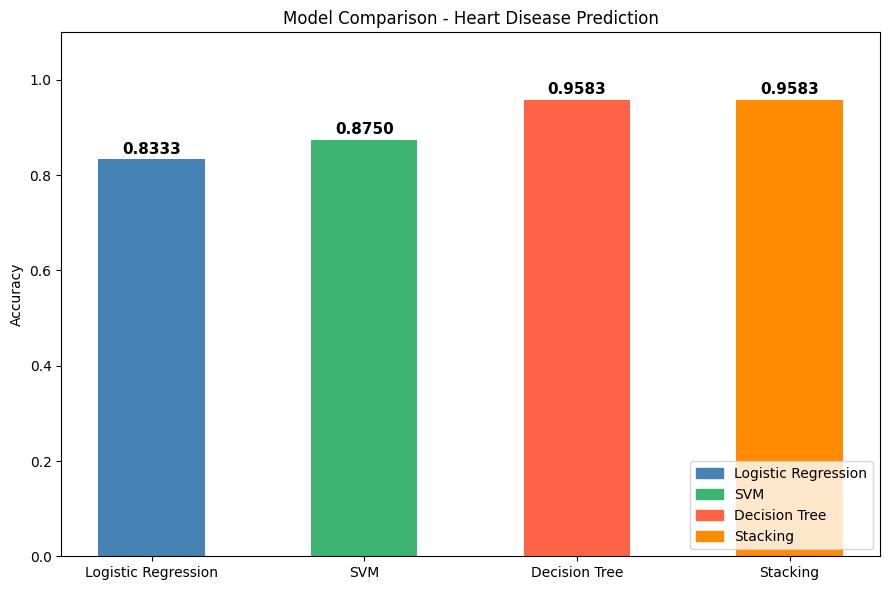

In [6]:
# Model comparison bar chart
models = ["Logistic Regression", "SVM", "Decision Tree", "Stacking"]
accuracies = [lr_acc, svm_acc, dt_acc, stack_acc]
colors = ["steelblue", "mediumseagreen", "tomato", "darkorange"]

plt.figure(figsize=(9, 6))
bars = plt.bar(models, accuracies, color=colors, width=0.5, label=models)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{acc:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.ylim(0, 1.1)
plt.title("Model Comparison - Heart Disease Prediction")
plt.ylabel("Accuracy")
import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=c, label=m) for c, m in zip(colors, models)]
plt.legend(handles=legend_patches, loc="lower right")
plt.tight_layout()
plt.savefig("scenario4_comparison.png", dpi=100)
plt.show()